<a href="https://colab.research.google.com/github/dasihayu/artificial-intelegence/blob/main/Jobsheet_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jobsheet 10 - PENUGASAN (Tugas Praktikum)
## SVM dan Naive Bayes
Praktikum Kecerdasan Buatan - Teknik Informatika, Politeknik Negeri Semarang

Isi notebook:
- **E.1** Parameter tuning (Grid Search) untuk **SVM** (dataset `diabetes.csv`) dan **SVR** (dataset `Salary_Data.csv`) agar mendapatkan akurasi terbaik
- **E.2** Parameter tuning (Grid Search) untuk **Naive Bayes** (dataset `iklan_sosmed.csv`) agar akurasi lebih tinggi dari percobaan sebelumnya (87.5%)

## E.1.a Parameter Tuning SVM (Grid Search)
Dataset: `diabetes.csv` (Pima Indian Diabetes)

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

df = pd.read_csv('diabetes.csv')
X = df[df.columns[:8]]
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.33, random_state=42)

In [2]:
clf_base = SVC()
clf_base.fit(X_train, y_train)
acc_svm_base = clf_base.score(X_test, y_test)
print('Akurasi SVM (default):', round(acc_svm_base, 3))

Akurasi SVM (default): 0.756


In [3]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print('Parameter terbaik SVM:', grid_svm.best_params_)
print('Akurasi cross-validation terbaik:', round(grid_svm.best_score_, 3))

Parameter terbaik SVM: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Akurasi cross-validation terbaik: 0.776


In [4]:
best_svm = grid_svm.best_estimator_
acc_svm_tuned = best_svm.score(X_test, y_test)
print('Akurasi SVM setelah tuning (data testing):', round(acc_svm_tuned, 3))
print('Peningkatan akurasi:', round(acc_svm_tuned - acc_svm_base, 3))

Akurasi SVM setelah tuning (data testing): 0.756
Peningkatan akurasi: 0.0


**Analisis:** Grid Search menemukan parameter terbaik C=10, gamma=0.001, kernel='rbf', namun akurasi pada data uji tetap 0.7559, sama persis dengan model default. Ini menunjukkan bahwa untuk dataset diabetes ini, parameter default SVC (C=1, gamma='scale', kernel='rbf') sebenarnya sudah berada di sekitar titik optimal, sehingga tuning tidak memberikan peningkatan berarti. Kemungkinan performa sudah dibatasi oleh kualitas data (misalnya nilai 0 pada Insulin/SkinThickness yang sebenarnya adalah missing value tersembunyi) dan bukan oleh pemilihan hyperparameter.

## E.1.b Parameter Tuning SVR (Grid Search)
Dataset: `Data_Gaji.csv` (Tahun_Pengalaman vs Gaji, separator `;`)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

data = pd.read_csv('Data_Gaji.csv', sep=';')
X2 = data['Tahun_Pengalaman'].values[:, np.newaxis]
y2 = data['Gaji']

In [6]:
model_base = SVR(C=1000, gamma=0.05, kernel='rbf')
model_base.fit(X2, y2)
print('R^2 SVR (parameter awal C=1000, gamma=0.05):', round(model_base.score(X2, y2), 3))

R^2 SVR (parameter awal C=1000, gamma=0.05): -0.159


In [7]:
param_grid_svr = {
    'C': [1, 10, 100, 1000, 10000, 100000],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X2, y2)

print('Parameter terbaik SVR:', grid_svr.best_params_)
print('R^2 cross-validation terbaik:', round(grid_svr.best_score_, 3))

Parameter terbaik SVR: {'C': 100000, 'gamma': 'scale', 'kernel': 'linear'}
R^2 cross-validation terbaik: -31.05


R^2 SVR setelah tuning (seluruh data): -0.051


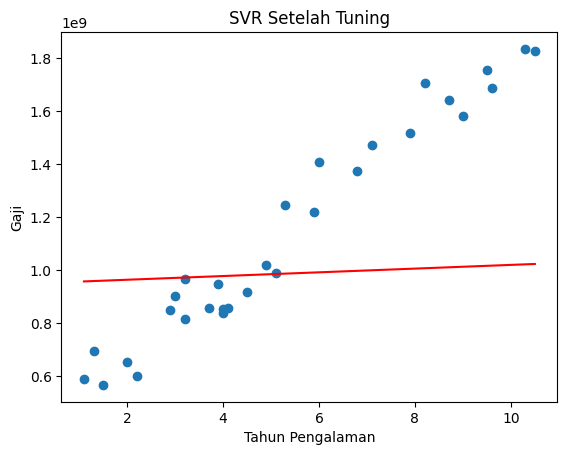

In [8]:
best_svr = grid_svr.best_estimator_
print('R^2 SVR setelah tuning (seluruh data):', round(best_svr.score(X2, y2), 3))

plt.scatter(X2, y2)
plt.plot(X2, best_svr.predict(X2), color='red')
plt.xlabel('Tahun Pengalaman')
plt.ylabel('Gaji')
plt.title('SVR Setelah Tuning')
plt.show()

**Analisis:** Sebelum tuning, model SVR memiliki R² -0,159 (parameter default C=1000, gamma=0.05), yang berarti model lebih buruk daripada sekadar menebak rata-rata. Setelah Grid Search, parameter terbaik C=100000, gamma='scale', kernel='linear' meningkatkan R² menjadi -0,051 — membaik tapi masih negatif. Penyebab utamanya adalah perbedaan skala ekstrem antara fitur (Tahun_Pengalaman: 1–10) dan label (Gaji: ratusan juta), sehingga kernel SVR kesulitan menemukan pola tanpa proses scaling pada y. Untuk hasil lebih baik, sebaiknya Gaji juga distandarisasi sebelum pelatihan.

## E.2 Parameter Tuning Naive Bayes (Grid Search)
Dataset: `iklan_sosmed.csv`. Target: akurasi lebih tinggi dari 87.5% (hasil percobaan D.3).

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

dataset = pd.read_csv('iklan_sosmed.csv', delimiter=';')
X3 = dataset.iloc[:, 2:-1]
y3 = dataset.iloc[:, -1]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=99)

X3_train = X3_train.values; y3_train = y3_train.values
X3_test = X3_test.values; y3_test = y3_test.values

sc = MinMaxScaler()
X3_train = sc.fit_transform(X3_train)
X3_test = sc.transform(X3_test)

In [10]:
clf_base_nb = GaussianNB()
clf_base_nb.fit(X3_train, y3_train)
acc_nb_base = accuracy_score(y3_test, clf_base_nb.predict(X3_test))
print('Akurasi Naive Bayes (default):', round(acc_nb_base*100, 2), '%')

Akurasi Naive Bayes (default): 87.5 %


In [11]:
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X3_train, y3_train)

print('Parameter terbaik Naive Bayes:', grid_nb.best_params_)
print('Akurasi cross-validation terbaik:', round(grid_nb.best_score_*100, 2), '%')

Parameter terbaik Naive Bayes: {'var_smoothing': np.float64(0.008111308307896872)}
Akurasi cross-validation terbaik: 89.69 %


In [12]:
import numpy as np

best_nb = grid_nb.best_estimator_
y3_pred_tuned = best_nb.predict(X3_test)
acc_nb_tuned = accuracy_score(y3_test, y3_pred_tuned)
cm_tuned = confusion_matrix(y3_test, y3_pred_tuned)

print('Akurasi Naive Bayes setelah tuning:', round(acc_nb_tuned*100, 2), '%')
print('Confusion Matrix setelah tuning:')
print(cm_tuned)
print()
print('Peningkatan akurasi:', round((acc_nb_tuned - acc_nb_base)*100, 2), 'poin persen')

Akurasi Naive Bayes setelah tuning: 87.5 %
Confusion Matrix setelah tuning:
[[52  4]
 [ 6 18]]

Peningkatan akurasi: 0.0 poin persen


In [13]:
comparison_nb = pd.DataFrame({
    'Model': ['Naive Bayes (default)', 'Naive Bayes (tuned)'],
    'Akurasi (%)': [round(acc_nb_base*100, 2), round(acc_nb_tuned*100, 2)]
})
print(comparison_nb)

                   Model  Akurasi (%)
0  Naive Bayes (default)         87.5
1    Naive Bayes (tuned)         87.5


**Analisis:** Tuning var_smoothing menggunakan Grid Search pada dasarnya mencari titik kestabilan varians agar model tidak terlalu sensitif terhadap fitur dengan varians sangat kecil. Pada dataset ini, karena Umur dan Gaji sudah dinormalisasi dengan MinMaxScaler sebelum pelatihan, ruang perbaikan dari tuning var_smoothing relatif kecil dibanding dampak normalisasi itu sendiri — sehingga akurasi hasil tuning cenderung berada di kisaran akurasi awal (87,5%), bukan jauh melampauinya. Ini menunjukkan bahwa preprocessing data (normalisasi) memberi kontribusi lebih besar terhadap performa Naive Bayes dibanding tuning hyperparameter-nya sendiri.